# **Import Libraries**

In [248]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# **Lord Dataset**

In [249]:
df = pd.read_csv("/content/sample_data/laptop-selected-columns.csv")


# **Exploratory Data Analysis**

In [250]:
df.head()

,Unnamed: 0,Model,Price,Rating,Generation,Core,Ram,SSD,Display,Graphics
0,0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,"₹50,399",70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8 GB DDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M
1,1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,"₹23,990",56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8 GB LPDDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics
2,2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,"₹26,989",55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",8 GB LPDDR5 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics
3,3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,"₹69,990",60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16 GB LPDDR5 RAM,512 GB SSD,"13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics
4,4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,"₹1,02,990",78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",16 GB DDR5 RAM,1 TB SSD,"16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060


In [251]:
df = df.drop(columns=["Unnamed: 0"])

In [252]:
df.shape

(920, 9)

In [253]:
df.columns

Index(['Model', 'Price', 'Rating', 'Generation', 'Core', 'Ram', 'SSD',
       'Display', 'Graphics'],
      dtype='object')

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Model       920 non-null    object 
 1   Price       920 non-null    object 
 2   Rating      768 non-null    float64
 3   Generation  920 non-null    object 
 4   Core        920 non-null    object 
 5   Ram         920 non-null    object 
 6   SSD         920 non-null    object 
 7   Display     919 non-null    object 
 8   Graphics    920 non-null    object 
dtypes: float64(1), object(8)
memory usage: 64.8+ KB


In [255]:
df.describe()

,Rating
count,768.000000
mean,61.756510
std,7.114217
min,50.000000
25%,56.000000
50%,61.500000
75%,66.000000
max,79.000000


In [256]:
df.isnull().sum()

,0
Model,0
Price,0
Rating,152
Generation,0
Core,0
Ram,0
SSD,0
Display,1
Graphics,0


In [257]:
df_edited  = df.copy()
df_edited = df_edited.dropna(subset=["Display"])

In [258]:
df_edited['Model'].value_counts()
df_edited['Brand'] = df_edited['Model'].str.split().str[0]

df_edited['Rating'] = df_edited['Rating'].fillna(df_edited.groupby('Brand')['Rating'].transform('mean'))
df_edited['Rating'] = df_edited['Rating'].fillna(df_edited['Rating'].mean())

df_edited = df_edited.drop(columns = ['Brand'])

In [259]:
df_edited.isnull().sum()

,0
Model,0
Price,0
Rating,0
Generation,0
Core,0
Ram,0
SSD,0
Display,0
Graphics,0


# **Data Cleaning And Feature Engeneering**

In [260]:
df_edited['Price'] = df_edited['Price'].str.replace('₹', '')
df_edited['Price'] = df_edited['Price'].str.replace(',', '')
df_edited['Price'] = df_edited['Price'].astype(int)

In [261]:
df_edited = df_edited[~(df_edited['SSD'].str.len() > 20)]

In [262]:
df_edited = df_edited[~(df_edited['SSD'] == 'Intel Arc Graphics')]

In [263]:
df_edited['SSD'].value_counts()

,count
SSD,
512 GB SSD,619
1 TB SSD,216
256 GB SSD,36
2 TB SSD,17
128 GB SSD,6
128 GB Hard Disk,6
1 TB Hard Disk,5
64 GB Hard Disk,3
64 GB SSD,3


In [264]:
#function to convert SSD into storage and is_ssd
def clean_Column_ssd(text):
  text = str(text).lower().strip()
  is_ssd = 1 if 'ssd' in text else 0 # 1 for ssd and 0 for harddisk

  try:
    size = int(''.join(filter(str.isdigit, text)))
  except ValueError:
    return np.nan , np.nan

  if 'tb' in text:
    size *= 1024

  return size , is_ssd


df_edited['Storage'] = df_edited['SSD'].apply(lambda x : clean_Column_ssd(x)[0])
df_edited['is_ssd'] = df_edited['SSD'].apply(lambda x : clean_Column_ssd(x)[1])

In [265]:
df_edited = df_edited.drop(columns =['SSD'])

In [266]:
df_edited.head()

,Model,Price,Rating,Generation,Core,Ram,Display,Graphics,Storage,is_ssd
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,50399,70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8 GB DDR4 RAM,"15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M,512,1
1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8 GB LPDDR4 RAM,"15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics,512,1
2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,26989,55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",8 GB LPDDR5 RAM,"15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics,512,1
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,69990,60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16 GB LPDDR5 RAM,"13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics,512,1
4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,102990,78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",16 GB DDR5 RAM,"16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060,1024,1


In [267]:
num_cols = df_edited.select_dtypes(include = 'number').columns
num_cols

Index(['Price', 'Rating', 'Storage', 'is_ssd'], dtype='object')

In [268]:
df_edited['is_ssd'].value_counts()

,count
is_ssd,
1,898
0,15


In [269]:
print(df_edited['Ram'].unique())

['8\u2009GB DDR4 RAM' '8\u2009GB LPDDR4 RAM' '8\u2009GB LPDDR5 RAM'
 '16\u2009GB LPDDR5 RAM' '16\u2009GB DDR5 RAM' '16\u2009GB DDR4 RAM'
 '8\u2009GB  RAM' '16\u2009GB LPDDR4x RAM' '32\u2009GB LPDDR5 RAM'
 '16\u2009GB LPDDR5x RAM' '16\u2009GB LPDDR5X RAM'
 '16\u2009GB DDR5 SDRAM RAM' '4\u2009GB DDR4 RAM' '8\u2009GB LPDDR4x RAM'
 '32\u2009GB DDR5 RAM' '32\u2009GB LPDDR4X RAM' '32\u2009GB LPDDR5X RAM'
 '48\u2009GB  RAM' '16\u2009GB LPDDR4X RAM' '4\u2009GB LPDDR4X RAM'
 '16\u2009GB LPDDR4 RAM' '2\u2009GB DDR3 RAM' '16\u2009GB  RAM'
 '32\u2009GB LPDDR5x RAM' '64\u2009GB DDR5 RAM' '8\u2009GB  DDR4 RAM'
 '36\u2009GB  RAM' '18\u2009GB  RAM' '8\u2009GB DDR5 RAM'
 '12\u2009GB LPDDR4 RAM' '8\u2009GB LPDDR4X RAM' '8\u2009GB DDR4  RAM'
 '16\u2009GB LPDDR5  RAM' '16\u2009GB DDR4  RAM' '16\u2009GB LPDDRx4 RAM'
 '32\u2009GB DDR4 RAM' '8\u2009GB DDR3 RAM' '16\u2009GB DDR6 RAM'
 '12\u2009GB LPDDR3 RAM' '4\u2009GB LPDDR4 RAM' '8\u2009GB LPDDR5  RAM'
 '16\u2009GB DDR5  RAM' '16\u2009GB  LPDDR5 RAM' '16\u2

In [270]:
# function to seperate ram size and type
def ram_cleaner(text):
    text = str(text).lower()

    text = text.replace('\u2009', ' ').replace('ram', '').strip()

    size_match = re.search(r'\d+', text)
    size = int(size_match.group()) if size_match else np.nan

    if 'lpddr6' in text:
        ram_type = 'LPDDR6'
    elif 'ddr6' in text:
        ram_type = 'DDR6'

    elif 'lpddr5' in text or 'pddr5' in text:
        ram_type = 'LPDDR5'
    elif 'ddr5' in text:
        ram_type = 'DDR5'

    elif 'lpddr4' in text or 'lpddrx4' in text:
        ram_type = 'LPDDR4'
    elif 'ddr4' in text:
        ram_type = 'DDR4'
    elif 'lpddr3' in text:
        ram_type = 'LPDDR3'
    elif 'ddr3' in text:
        ram_type = 'DDR3'

    else:
        ram_type = 'UNKNOWN'

    return size, ram_type

df_edited['Ram_size'] = df_edited['Ram'].apply(lambda x: ram_cleaner(x)[0])
df_edited['Ram_type'] = df_edited['Ram'].apply(lambda x: ram_cleaner(x)[1])

In [271]:
df_edited = df_edited[~(df_edited['Ram_type'] == 'UNKNOWN')]
df_edited = df_edited.drop(columns=['Ram'])

In [272]:
df_edited = pd.get_dummies(df_edited, columns=['Ram_type'], drop_first=True, dtype=int)

In [273]:
df_edited.head()

,Model,Price,Rating,Generation,Core,Display,Graphics,Storage,is_ssd,Ram_size,Ram_type_DDR4,Ram_type_DDR5,Ram_type_DDR6,Ram_type_LPDDR3,Ram_type_LPDDR4,Ram_type_LPDDR5
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,50399,70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads","15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M,512,1,8,1,0,0,0,0,0
1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads","15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics,512,1,8,0,0,0,0,1,0
2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,26989,55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads","15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics,512,1,8,0,0,0,0,0,1
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,69990,60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads","13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics,512,1,16,0,0,0,0,0,1
4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,102990,78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads","16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060,1024,1,16,0,1,0,0,0,0


In [274]:
def clean_display_column(text):
    text = str(text).lower().strip()

    if 'inch' not in text and 'x' not in text:
        return np.nan, np.nan, np.nan, np.nan

    size_match = re.search(r'(\d+\.?\d*)\s*inch', text)
    display_size = float(size_match.group(1)) if size_match else np.nan

    res_match = re.search(r'(\d+)\s*[xX]\s*(\d+)', text)
    if res_match:
        res_width = int(res_match.group(1))
        res_height = int(res_match.group(2))
    else:
        res_width, res_height = np.nan, np.nan

    is_touch = 1 if 'touch' in text else 0

    return display_size, res_width, res_height, is_touch

df_edited[['display_size', 'res_width', 'res_height', 'is_touch']] = df_edited['Display'].apply(
    lambda x: pd.Series(clean_display_column(x))
)

df_edited = df_edited.dropna(subset=['display_size', 'res_width', 'res_height'])

In [275]:
df_edited.shape

(884, 20)

In [276]:
df_edited = df_edited.drop(columns = ['Display'])
df_edited['is_touch'] = df_edited['is_touch'].astype(int)
df_edited['ppi'] = (np.sqrt(
    df_edited['res_width']**2 + df_edited['res_height']**2
) / df_edited['display_size']).round(2)

df_edited = df_edited.drop(columns = ['res_width' , 'res_height'])
df_edited.head()

,Model,Price,Rating,Generation,Core,Graphics,Storage,is_ssd,Ram_size,Ram_type_DDR4,Ram_type_DDR5,Ram_type_DDR6,Ram_type_LPDDR3,Ram_type_LPDDR4,Ram_type_LPDDR5,display_size,is_touch,ppi
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,50399,70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",4 GB AMD Radeon RX 6500M,512,1,8,1,0,0,0,0,0,15.6,1,141.21
1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",Intel UHD Graphics,512,1,8,0,0,0,0,1,0,15.6,0,141.21
2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,26989,55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",AMD Radeon Graphics,512,1,8,0,0,0,0,0,1,15.6,0,141.21
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,69990,60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",Intel Iris Xe Graphics,512,1,16,0,0,0,0,0,1,13.3,0,165.63
4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,102990,78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",8 GB NVIDIA GeForce RTX 4060,1024,1,16,0,1,0,0,0,0,16.1,0,187.51


In [277]:
core_map = {
    'dual': 2,
    'quad': 4,
    'hexa': 6,
    'octa': 8
}

def extract_core_count(text):
    text = str(text).strip().lower()

    m = re.search(r'(\d+)\s*cores?', text)
    if m:
        return int(m.group(1))

    for name, value in core_map.items():
        if name in text:
            return value

    return np.nan

def extract_thread_count(text):
    text = str(text).strip().lower()

    m = re.search(r'(\d+)\s*threads?', text)
    if m:
        return int(m.group(1))

    return np.nan

df_edited['core_count'] = df_edited['Core'].apply(extract_core_count)
df_edited['thread_count'] = df_edited['Core'].apply(extract_thread_count)


df_edited = df_edited[df_edited['core_count'].notna()]
df_edited = df_edited[df_edited['thread_count'].notna()]

df_edited['core_count'] = df_edited['core_count'].astype(int)
df_edited['thread_count'] = df_edited['thread_count'].astype(int)

df_edited.drop(columns=['Core'], inplace=True)

df_edited.head()

,Model,Price,Rating,Generation,Graphics,Storage,is_ssd,Ram_size,Ram_type_DDR4,Ram_type_DDR5,Ram_type_DDR6,Ram_type_LPDDR3,Ram_type_LPDDR4,Ram_type_LPDDR5,display_size,is_touch,ppi,core_count,thread_count
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,50399,70.0,5th Gen AMD Ryzen 5 5600H,4 GB AMD Radeon RX 6500M,512,1,8,1,0,0,0,0,0,15.6,1,141.21,6,12
1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,56.0,11th Gen Intel Core i3 1115G4,Intel UHD Graphics,512,1,8,0,0,0,0,1,0,15.6,0,141.21,2,4
2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,26989,55.0,7th Gen AMD Ryzen 3 7320U,AMD Radeon Graphics,512,1,8,0,0,0,0,0,1,15.6,0,141.21,4,8
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,69990,60.0,12th Gen Intel Core i5 1240P,Intel Iris Xe Graphics,512,1,16,0,0,0,0,0,1,13.3,0,165.63,12,16
4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,102990,78.0,14th Gen Intel Core i9 14900HX,8 GB NVIDIA GeForce RTX 4060,1024,1,16,0,1,0,0,0,0,16.1,0,187.51,24,32


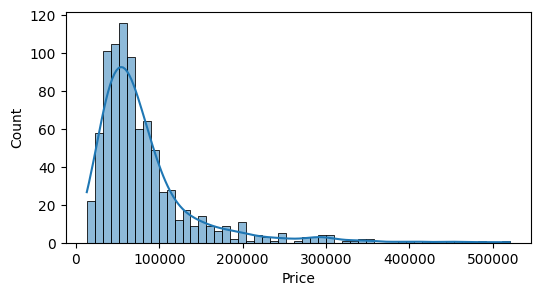

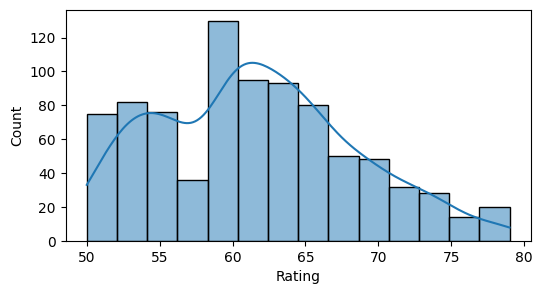

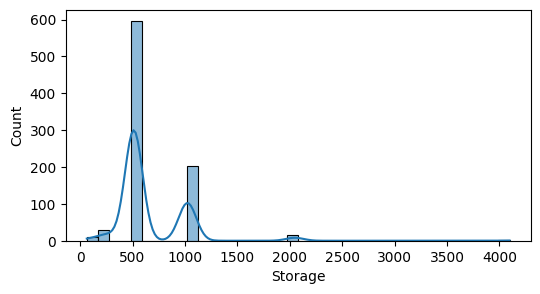

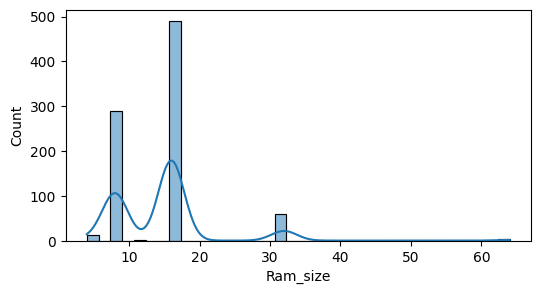

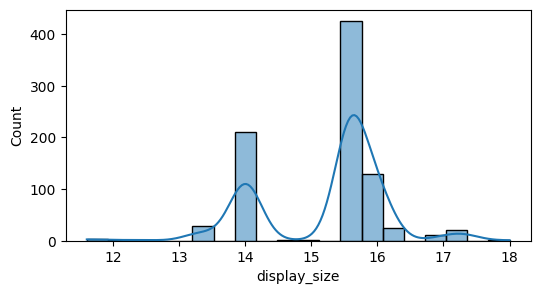

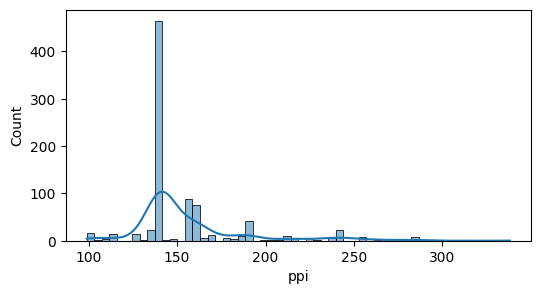

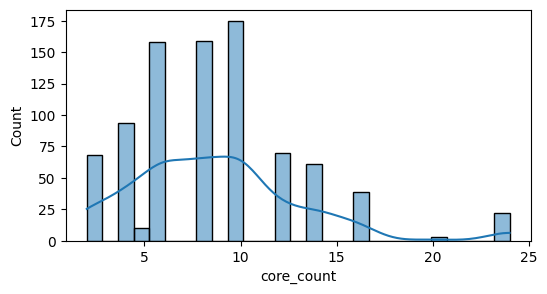

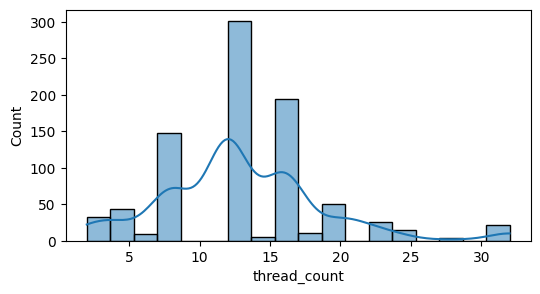

In [278]:
cols = ['Price' , 'Rating' , 'Storage' ,'Ram_size' , 'display_size', 'ppi', 'core_count', 'thread_count']
for col in cols:
  plt.figure(figsize=(6, 3))
  sns.histplot(df_edited[col] , kde = True)
  plt.show()

# **Feature Scaling**

In [279]:
cols = ['Model' , 'Generation' , 'Graphics']
all_cols = df_edited.drop(columns = ['Price' , 'is_ssd', 'Ram_type_DDR4', 'Ram_type_DDR5', 'Ram_type_DDR6', 'Ram_type_LPDDR3', 'Ram_type_LPDDR4', 'Ram_type_LPDDR5' , 'is_touch']).columns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
for col in cols:
  le = LabelEncoder()
  df_edited[col] = le.fit_transform(df_edited[col])

sclar = StandardScaler()
df_edited[all_cols] = sclar.fit_transform(df_edited[all_cols])

In [280]:
df_edited.head()

,Model,Price,Rating,Generation,Graphics,Storage,is_ssd,Ram_size,Ram_type_DDR4,Ram_type_DDR5,Ram_type_DDR6,Ram_type_LPDDR3,Ram_type_LPDDR4,Ram_type_LPDDR5,display_size,is_touch,ppi,core_count,thread_count
0,0.100818,50399,1.241798,0.537289,-1.773617,-0.430846,1,-0.912437,1,0,0,0,0,0,0.384945,1,-0.451367,-0.599862,-0.173082
1,1.633250,23990,-0.832490,-1.366135,1.284799,-0.430846,1,-0.912437,0,0,0,0,1,0,0.384945,0,-0.451367,-1.502281,-1.557740
2,1.092866,26989,-0.980654,0.976541,-0.085117,-0.430846,1,-0.912437,0,0,0,0,0,1,0.384945,0,-0.451367,-1.051071,-0.865411
3,1.625185,69990,-0.239836,-0.853674,1.093648,-0.430846,1,0.222658,0,0,0,0,0,1,-2.035990,0,0.307704,0.753767,0.519247
4,1.697774,102990,2.427105,0.195649,-0.594853,1.142361,1,0.222658,0,1,0,0,0,0,0.911236,0,0.987822,3.461023,3.288562


# Data Outlier Detection

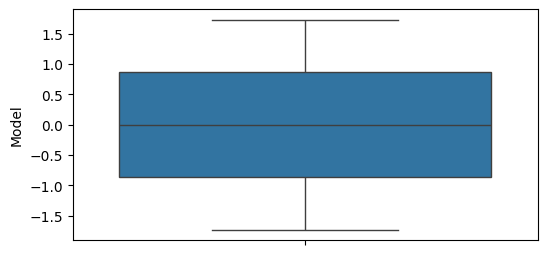

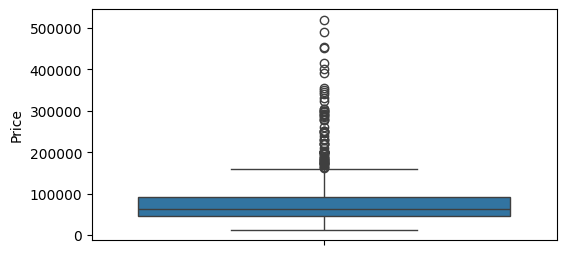

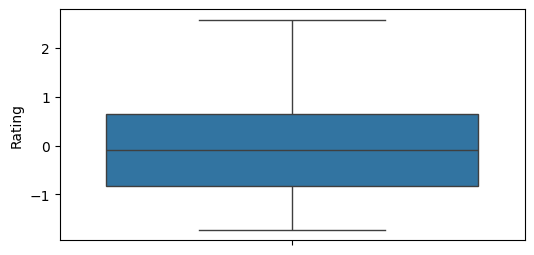

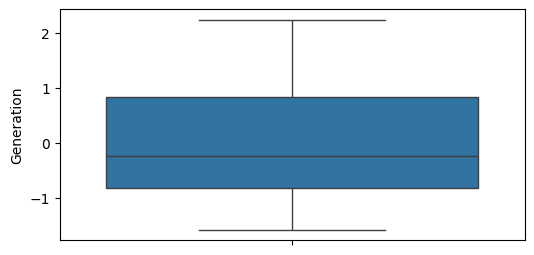

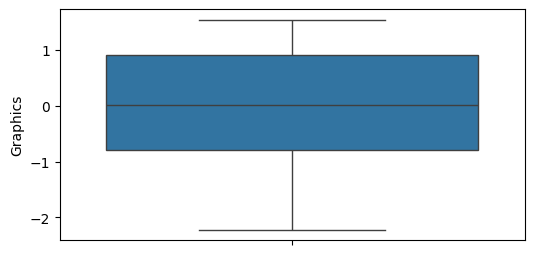

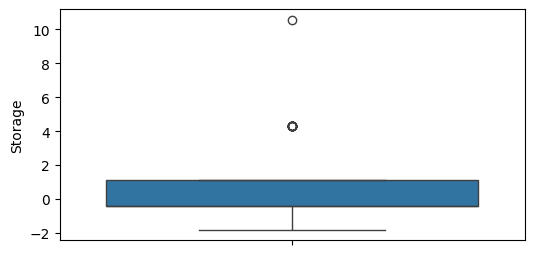

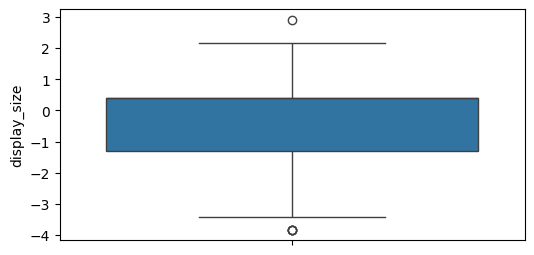

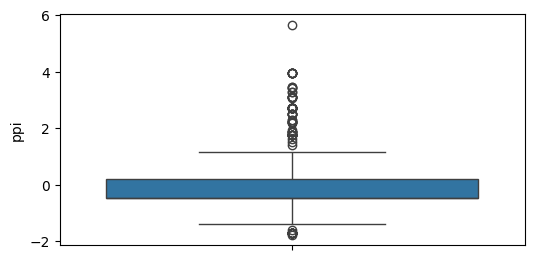

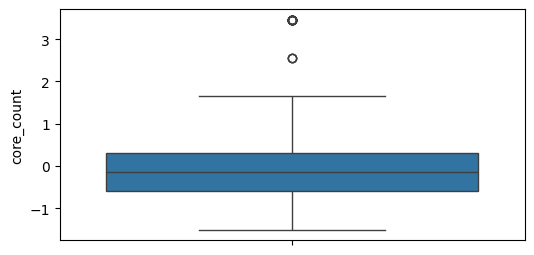

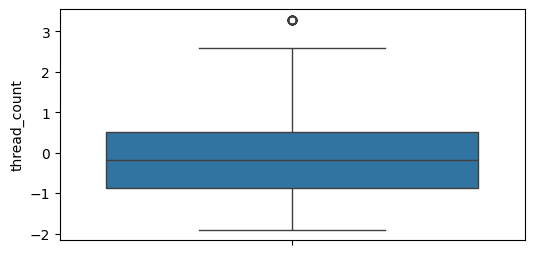

In [281]:
num_cols = df_edited.select_dtypes(include = 'number').drop(columns = ['is_ssd', 'Ram_size', 'Ram_type_DDR4', 'Ram_type_DDR5', 'Ram_type_DDR6', 'Ram_type_LPDDR3', 'Ram_type_LPDDR4', 'Ram_type_LPDDR5' , 'is_touch']).columns
for col in num_cols:
  plt.figure(figsize=(6, 3))
  sns.boxplot(df_edited[col])
  plt.show()

# Correlation HeatMap

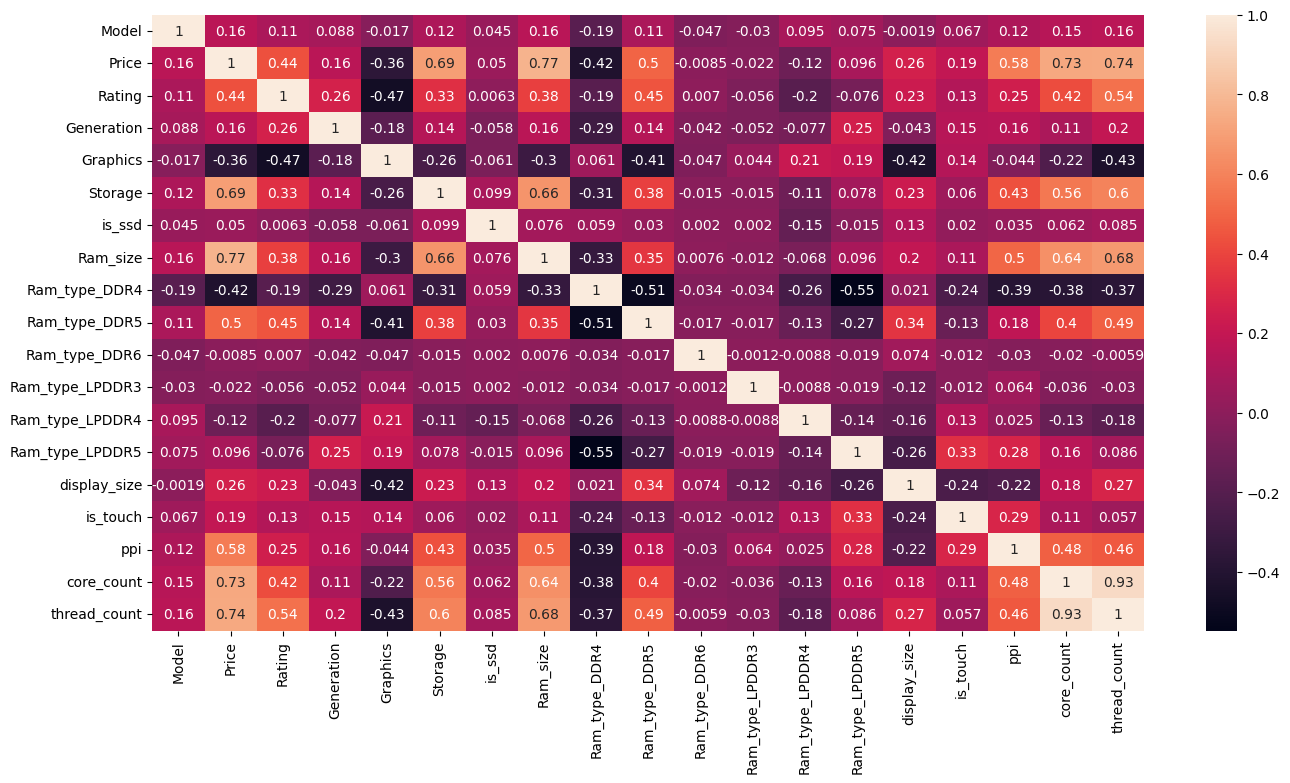

In [282]:
plt.figure(figsize=(16, 8))
sns.heatmap(df_edited.corr(), annot=True)
plt.show()

# Pearson Correlation Analysis

In [283]:
from scipy.stats import pearsonr
cols = df_edited.drop(columns =['Price']).columns

correlation = {
    feature : pearsonr(df_edited[feature] , df_edited['Price'])[0] for feature in cols
}

correlation_df = pd.DataFrame(list(correlation.items()) , columns = ['Feature' , 'Correlation'])
correlation_df = correlation_df.sort_values(by = 'Correlation' , ascending = False)
correlation_df

,Feature,Correlation
6,Ram_size,0.772557
17,thread_count,0.736990
16,core_count,0.728617
4,Storage,0.693244
15,ppi,0.576401
8,Ram_type_DDR5,0.496887
1,Rating,0.435809
13,display_size,0.257952
14,is_touch,0.193454
2,Generation,0.163744


In [284]:
df_edited = df_edited.drop(columns = ['Model', 'Ram_type_DDR6', 'Ram_type_LPDDR3' ,'Ram_type_LPDDR5' , 'is_ssd'])

In [285]:
df_edited.head()

,Price,Rating,Generation,Graphics,Storage,Ram_size,Ram_type_DDR4,Ram_type_DDR5,Ram_type_LPDDR4,display_size,is_touch,ppi,core_count,thread_count
0,50399,1.241798,0.537289,-1.773617,-0.430846,-0.912437,1,0,0,0.384945,1,-0.451367,-0.599862,-0.173082
1,23990,-0.832490,-1.366135,1.284799,-0.430846,-0.912437,0,0,1,0.384945,0,-0.451367,-1.502281,-1.557740
2,26989,-0.980654,0.976541,-0.085117,-0.430846,-0.912437,0,0,0,0.384945,0,-0.451367,-1.051071,-0.865411
3,69990,-0.239836,-0.853674,1.093648,-0.430846,0.222658,0,0,0,-2.035990,0,0.307704,0.753767,0.519247
4,102990,2.427105,0.195649,-0.594853,1.142361,0.222658,0,1,0,0.911236,0,0.987822,3.461023,3.288562


# Model Training

In [286]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error


X = df_edited.drop(columns=['Price'])
y = df_edited['Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n = X_test.shape[0]
p = X_test.shape[1]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Bayesian Ridge": BayesianRidge(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=9),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results[name] = {
        "R² Score": round(r2, 4),
        "adj_r2" : 1 - (1 - r2) * (n - 1) / (n - p - 1),
        "Avg Error (MAE)": round(mae, 2)
    }

results_df = pd.DataFrame.from_dict(results , orient='index').sort_values(by ="R² Score", ascending=False)
results_df

,R² Score,adj_r2,Avg Error (MAE)
KNN Regressor,0.8370,0.823639,14307.01
Bayesian Ridge,0.7938,0.776888,17893.83
Ridge Regression,0.7927,0.775598,17926.45
Linear Regression,0.7921,0.774961,17942.66
Decision Tree,0.7556,0.735482,15521.39


# Cross Validation

In [287]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    models['KNN Regressor'], X , y, cv=5, scoring='r2'
)

print("Fold Scores:", scores)
print("Mean R²:", np.mean(scores))
print("Std Dev:", np.std(scores))

Fold Scores: [0.77506551 0.80170688 0.70823105 0.77826626 0.78874579]
Mean R²: 0.7704030979892988
Std Dev: 0.03245092409945539


# Hyperparameter Tuning

In [288]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(models['KNN Regressor'], param_grid, cv=5, scoring='r2')
grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV R²:")
print(grid.best_score_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

Best CV R²:
0.8055093633205642


In [289]:
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

random_search = RandomizedSearchCV(
    estimator=models['KNN Regressor'],
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42
)

random_search.fit(X, y)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV R²:")
print(random_search.best_score_)

Best Parameters:
{'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}

Best CV R²:
0.8040806822754852


In [290]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2',
)

print("Fold Scores:", scores)
print("Mean CV R²:", np.mean(scores))
print("Std Dev:", np.std(scores))

Fold Scores: [0.7905948  0.80959313 0.78341477 0.82097927 0.82757061]
Mean CV R²: 0.8064305134413405
Std Dev: 0.01702390420138907


In [291]:
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42
)

random_search.fit(X, y)

print("Best Params:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
Best CV R²: 0.8201454262102971


# Residual Analysis(Random Forest)

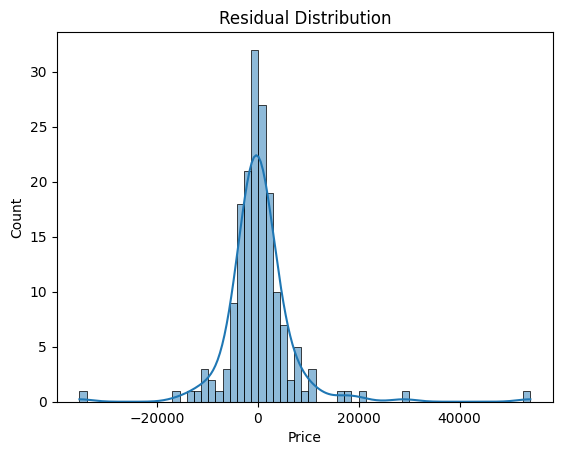

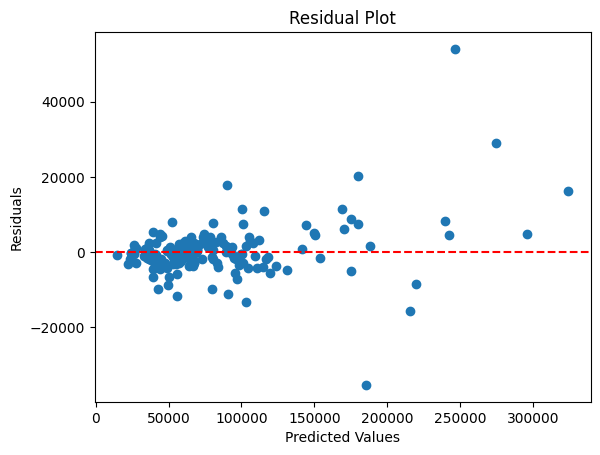

In [295]:
y_pred = random_search.predict(X_test)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [292]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2',
)

print(scores.mean())

0.8004605054855347


# Conclusion

The Random Forest model was selected as the final model as it achieved the best performance among all tested models with a CV R² score of approximately 0.82.

Feature engineering played a more significant role than model complexity in improving performance, especially the transformation of CPU specifications into core_count and thread_count, and the creation of PPI from display resolution.

RAM size, graphics type, processor threads, and PPI were the most important features influencing laptop price prediction.

Overall, the model provides a reliable estimation of laptop prices based on hardware specifications.